# NSE Stock Direction Prediction — Model
**Course:** Data Analytics and Visualization  
**Model:** Logistic Regression  
**Task:** Predict next-day price direction (UP / DOWN) using technical indicators

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

FEATURES = [
    'rsi', 'macd_hist', 'bb_pct_b', 'atr_pct',
    'rolling_vol_20', 'obv_ema', 'ema_20_50_cross', 'ema_50_200_cross'
]
TARGET = 'target'

SECTOR_COLORS = {
    'IT':      '#4C72B0',
    'Banking': '#DD8452',
    'Auto':    '#55A868',
    'FMCG':   '#C44E52',
    'Energy':  '#8172B2',
}

print('Libraries loaded.')

Libraries loaded.


## 1. Load Data

In [2]:
df = pd.read_csv('combined.csv', index_col=0, parse_dates=True)
df.index = pd.to_datetime(df.index)

print(f'Shape: {df.shape}')
print(f'Tickers: {sorted(df["ticker"].unique())}')
print(f'\nFeatures used: {FEATURES}')
print(f'Target: {TARGET}  (1 = price UP next day, 0 = price DOWN)')

# Class balance check across all stocks
balance = df[TARGET].value_counts(normalize=True) * 100
print(f'\nOverall class balance — UP: {balance[1]:.1f}%  DOWN: {balance[0]:.1f}%')

Shape: (24240, 36)
Tickers: ['AXISBANK.NS', 'HDFCBANK.NS', 'HEROMOTOCO.NS', 'HINDUNILVR.NS', 'INFY.NS', 'ITC.NS', 'M&M.NS', 'MARUTI.NS', 'NESTLEIND.NS', 'NTPC.NS', 'ONGC.NS', 'POWERGRID.NS', 'SBIN.NS', 'TCS.NS', 'WIPRO.NS']

Features used: ['rsi', 'macd_hist', 'bb_pct_b', 'atr_pct', 'rolling_vol_20', 'obv_ema', 'ema_20_50_cross', 'ema_50_200_cross']
Target: target  (1 = price UP next day, 0 = price DOWN)

Overall class balance — UP: 48.4%  DOWN: 51.6%


## 2. What is Logistic Regression?

Logistic Regression is a **binary classification** model. Given a set of input features (RSI, MACD, etc.), it outputs the probability that the next day's price will go UP.

**How it works:**
1. Computes a weighted sum of all input features:
   `z = w1×RSI + w2×MACD_hist + w3×BB_pct_b + ... + bias`
2. Passes `z` through the **sigmoid function** to get a probability between 0 and 1:
   `P(UP) = 1 / (1 + e^(-z))`
3. Predicts **UP** if `P > 0.5`, else **DOWN**

The weights (`w1, w2, ...`) are learned from training data. A positive weight means that indicator pushes toward predicting UP. A negative weight means it pushes toward DOWN.

**Why time-based split?**  
We train on 2020–2023, test on 2024–2026. A random split would mix future data into training, which is cheating — the model would 'know' future market conditions during training.

## 3. Train One Model Per Stock

In [3]:
TRAIN_END = '2023-12-31'
TEST_START = '2024-01-01'

results = []
models  = {}   # store fitted models for later

for ticker in sorted(df['ticker'].unique()):
    stock = df[df['ticker'] == ticker].sort_index().dropna(subset=FEATURES + [TARGET])
    sector = stock['sector'].iloc[0]

    train = stock.loc[:TRAIN_END]
    test  = stock.loc[TEST_START:]

    if len(train) < 100 or len(test) < 30:
        print(f'  [SKIP] {ticker} — insufficient data')
        continue

    X_train, y_train = train[FEATURES], train[TARGET]
    X_test,  y_test  = test[FEATURES],  test[TARGET]

    # Scale features — critical because RSI (0-100) and OBV (millions) are on very different scales
    scaler  = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    # Fit logistic regression
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)

    # Metrics
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)

    # Store coefficients
    coef_dict = dict(zip(FEATURES, model.coef_[0]))

    results.append({
        'ticker':     ticker,
        'sector':     sector,
        'train_size': len(train),
        'test_size':  len(test),
        'accuracy':   round(acc * 100, 2),
        'precision':  round(prec * 100, 2),
        'recall':     round(rec * 100, 2),
        'f1':         round(f1 * 100, 2),
        **coef_dict
    })
    models[ticker] = (model, scaler, X_test_s, y_test, y_pred)

results_df = pd.DataFrame(results).set_index('ticker')
print('All models trained.\n')
print(results_df[['sector','accuracy','precision','recall','f1']].to_string())

All models trained.

                sector  accuracy  precision  recall     f1
ticker                                                    
AXISBANK.NS    Banking     46.79      45.83   80.00  58.28
HDFCBANK.NS    Banking     52.03      48.15   23.30  31.40
HEROMOTOCO.NS     Auto     46.28      46.17   72.18  56.32
HINDUNILVR.NS     FMCG     53.72      48.91   50.00  49.45
INFY.NS             IT     50.17      46.71   51.64  49.05
ITC.NS            FMCG     52.87      44.73   41.73  43.18
M&M.NS            Auto     52.87      51.34   72.41  60.09
MARUTI.NS         Auto     47.80      43.61   49.26  46.26
NESTLEIND.NS      FMCG     53.04      49.81   48.01  48.90
NTPC.NS         Energy     47.64      47.41   90.78  62.29
ONGC.NS         Energy     50.34      47.26   39.86  43.24
POWERGRID.NS    Energy     49.16      48.27   78.25  59.71
SBIN.NS        Banking     52.36      51.61   60.07  55.52
TCS.NS              IT     47.80      42.30   59.45  49.43
WIPRO.NS            IT     50.84   

## 4. Model Performance Summary

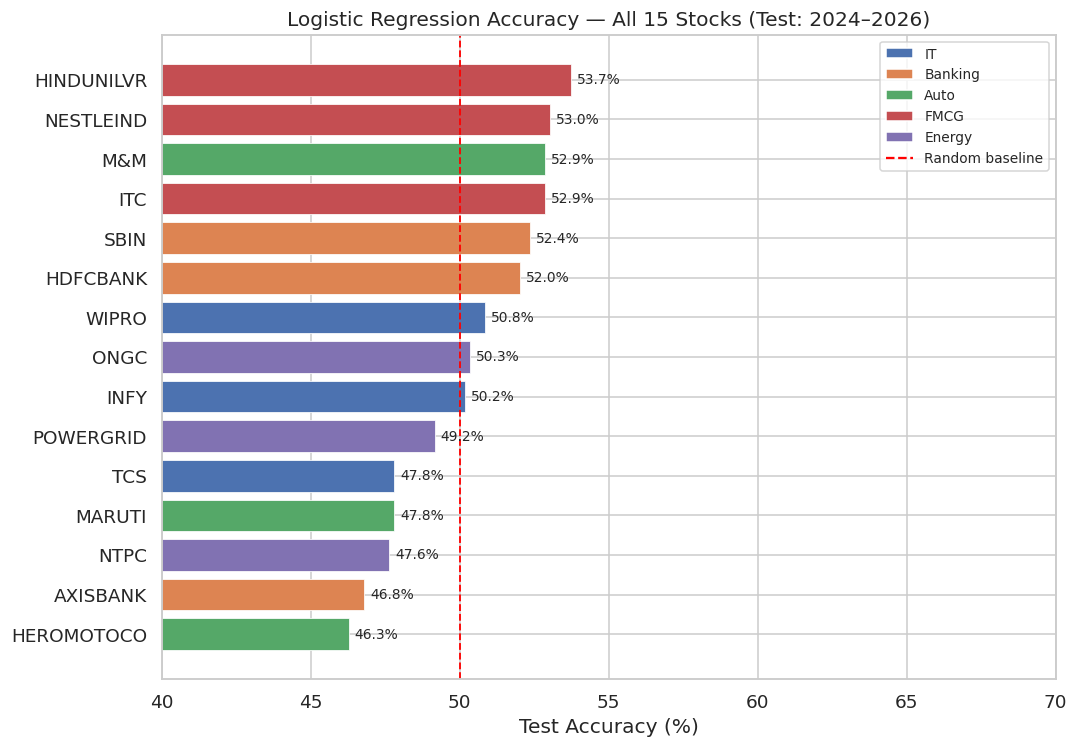

In [4]:
# ── 4.1 Accuracy bar chart — all 15 stocks ────────────────────────────────────
acc_sorted = results_df.sort_values('accuracy', ascending=True)
colors     = [SECTOR_COLORS[s] for s in acc_sorted['sector']]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(
    acc_sorted.index.str.replace('.NS', ''),
    acc_sorted['accuracy'],
    color=colors, edgecolor='white', linewidth=0.5
)
for bar, val in zip(bars, acc_sorted['accuracy']):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)

ax.axvline(50, color='red', linewidth=1.2, linestyle='--', label='Random baseline (50%)')
ax.set_xlabel('Test Accuracy (%)')
ax.set_title('Logistic Regression Accuracy — All 15 Stocks (Test: 2024–2026)')
ax.set_xlim(40, 70)

from matplotlib.patches import Patch
legend_els = [Patch(facecolor=c, label=s) for s, c in SECTOR_COLORS.items()]
legend_els.append(plt.Line2D([0],[0], color='red', linestyle='--', label='Random baseline'))
ax.legend(handles=legend_els, fontsize=9)

plt.tight_layout()
plt.savefig('model_01_accuracy.png', bbox_inches='tight')
plt.show()

Sector-average model performance:
         accuracy  precision  recall     f1
sector                                     
Auto        48.98      47.04   64.62  54.22
Banking     50.39      48.53   54.46  48.40
Energy      49.05      47.65   69.63  55.08
FMCG        53.21      47.82   46.58  47.18
IT          49.60      45.07   47.26  45.12


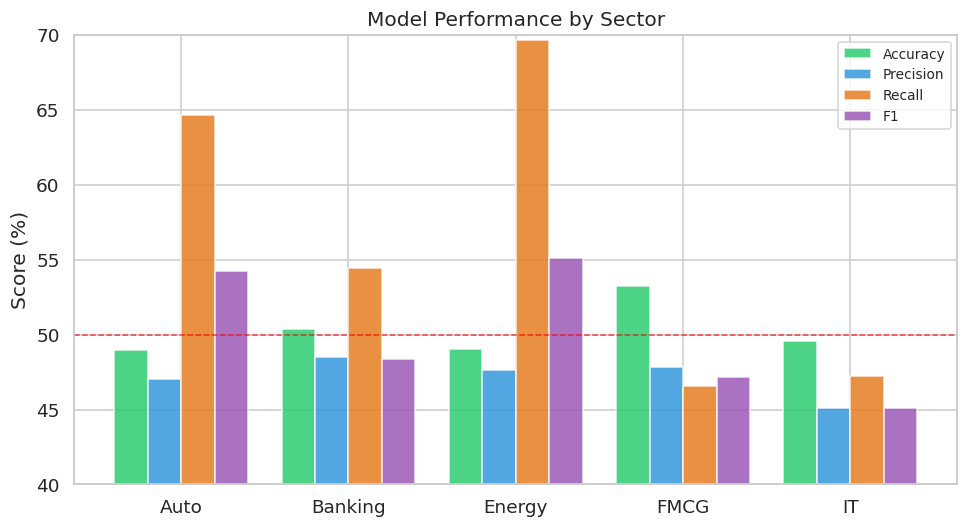

In [5]:
# ── 4.2 Sector-average metrics ────────────────────────────────────────────────
sector_avg = results_df.groupby('sector')[['accuracy','precision','recall','f1']].mean().round(2)
print('Sector-average model performance:')
print(sector_avg.to_string())

fig, ax = plt.subplots(figsize=(9, 5))
x     = np.arange(len(sector_avg))
width = 0.2
metrics = ['accuracy', 'precision', 'recall', 'f1']
metric_colors = ['#2ecc71', '#3498db', '#e67e22', '#9b59b6']

for i, (metric, color) in enumerate(zip(metrics, metric_colors)):
    ax.bar(x + i*width, sector_avg[metric], width, label=metric.capitalize(), color=color, alpha=0.85)

ax.axhline(50, color='red', linewidth=1, linestyle='--', alpha=0.7)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(sector_avg.index)
ax.set_ylabel('Score (%)')
ax.set_ylim(40, 70)
ax.set_title('Model Performance by Sector')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('model_02_sector_metrics.png', bbox_inches='tight')
plt.show()

## 5. Feature Importance — Which Indicator Matters Most?

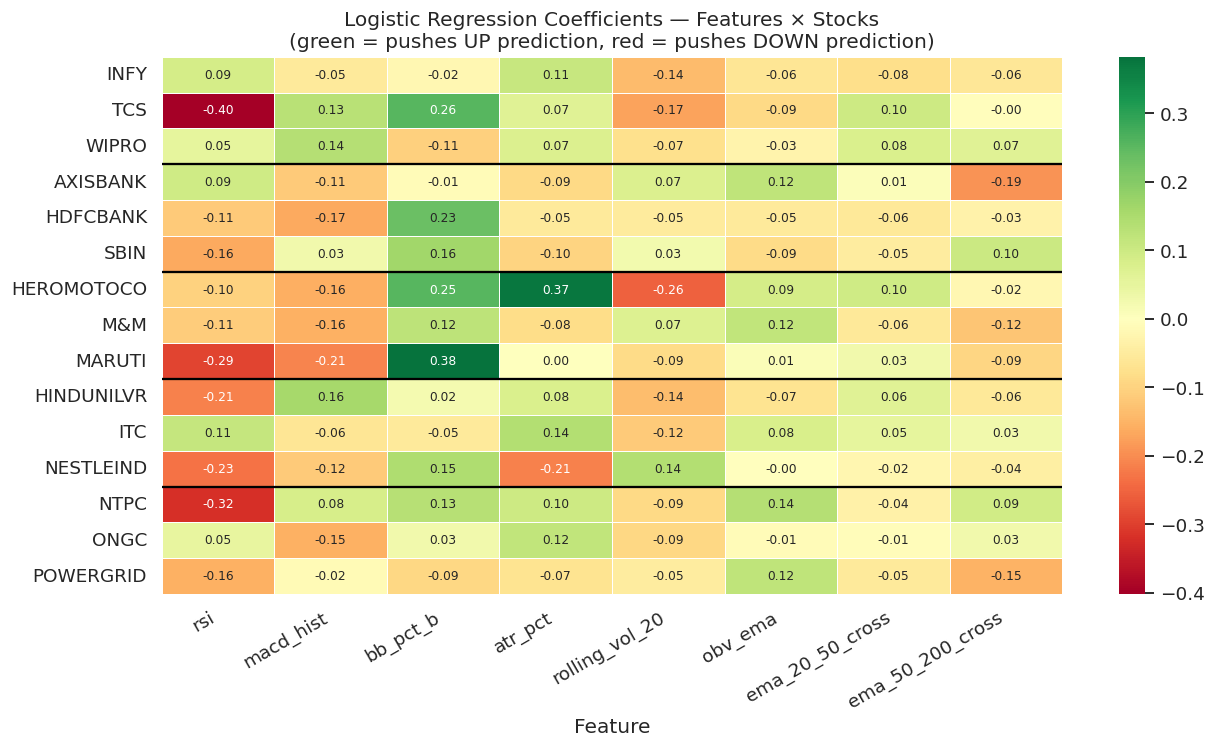

In [6]:
# ── 5.1 Coefficient heatmap — features × stocks ───────────────────────────────
# Rows = stocks (ordered by sector), Columns = features
# Positive coefficient = pushes toward predicting UP
# Negative coefficient = pushes toward predicting DOWN

sector_order = ['IT', 'Banking', 'Auto', 'FMCG', 'Energy']
ticker_order = []
for s in sector_order:
    tickers_in_sector = results_df[results_df['sector'] == s].index.tolist()
    ticker_order.extend(tickers_in_sector)

coef_df = results_df.loc[ticker_order, FEATURES].copy()
coef_df.index = coef_df.index.str.replace('.NS', '')

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(
    coef_df, cmap='RdYlGn', center=0,
    annot=True, fmt='.2f', linewidths=0.5,
    annot_kws={'size': 8}, ax=ax
)

# Sector dividers
for i in [3, 6, 9, 12]:
    ax.axhline(i, color='black', linewidth=1.5)

ax.set_title('Logistic Regression Coefficients — Features × Stocks\n(green = pushes UP prediction, red = pushes DOWN prediction)')
ax.set_xlabel('Feature')
ax.set_ylabel('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('model_03_coef_heatmap.png', bbox_inches='tight')
plt.show()

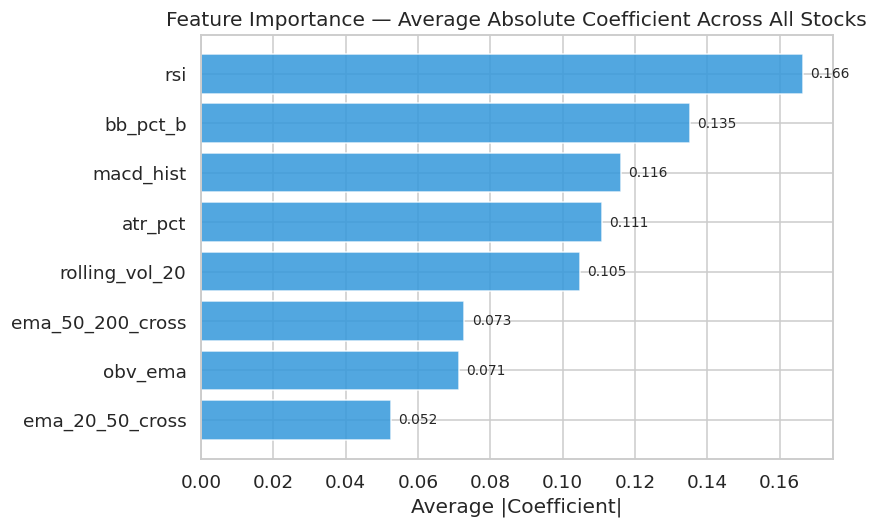

Most influential feature overall: rsi
Least influential feature overall: ema_20_50_cross


In [7]:
# ── 5.2 Average absolute coefficient per feature ──────────────────────────────
# Which indicator has the strongest influence on average across all 15 stocks?
avg_abs_coef = results_df[FEATURES].abs().mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(avg_abs_coef.index, avg_abs_coef.values,
               color='#3498db', alpha=0.85, edgecolor='white')
for bar, val in zip(bars, avg_abs_coef.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
ax.set_xlabel('Average |Coefficient|')
ax.set_title('Feature Importance — Average Absolute Coefficient Across All Stocks')
plt.tight_layout()
plt.savefig('model_04_feature_importance.png', bbox_inches='tight')
plt.show()

print('Most influential feature overall:', avg_abs_coef.idxmax())
print('Least influential feature overall:', avg_abs_coef.idxmin())

## 6. Confusion Matrices — Best and Worst Models

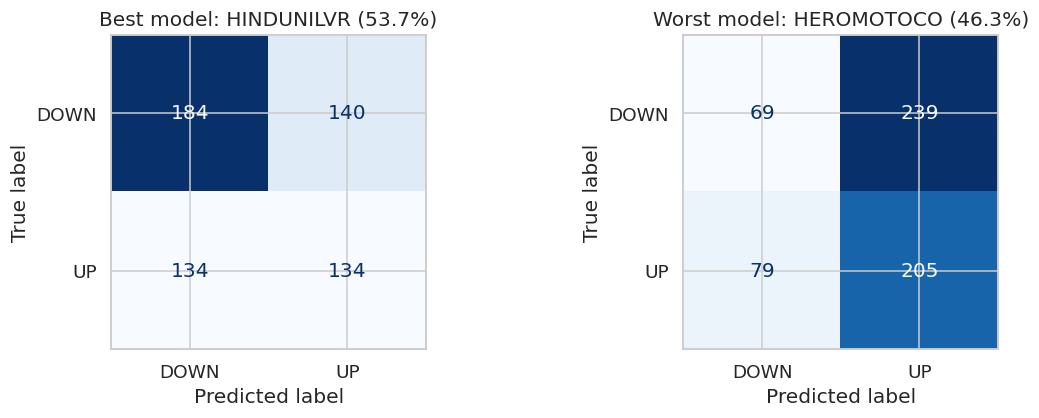

Best  model: HINDUNILVR.NS  — 53.7% accuracy
Worst model: HEROMOTOCO.NS — 46.3% accuracy


In [8]:
best_ticker  = results_df['accuracy'].idxmax()
worst_ticker = results_df['accuracy'].idxmin()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, ticker, label in [
    (axes[0], best_ticker,  'Best'),
    (axes[1], worst_ticker, 'Worst'),
]:
    _, _, _, y_test, y_pred = models[ticker]
    cm  = confusion_matrix(y_test, y_pred)
    acc = results_df.loc[ticker, 'accuracy']
    disp = ConfusionMatrixDisplay(cm, display_labels=['DOWN', 'UP'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{label} model: {ticker.replace(".NS","")} ({acc:.1f}%)')

plt.tight_layout()
plt.savefig('model_05_confusion_matrices.png', bbox_inches='tight')
plt.show()

print(f'Best  model: {best_ticker}  — {results_df.loc[best_ticker, "accuracy"]:.1f}% accuracy')
print(f'Worst model: {worst_ticker} — {results_df.loc[worst_ticker, "accuracy"]:.1f}% accuracy')

## 7. Key Findings and Interpretation

In [9]:
print('=' * 60)
print('MODEL SUMMARY')
print('=' * 60)
print(f'\nModel      : Logistic Regression')
print(f'Features   : {len(FEATURES)} technical indicators')
print(f'Train split: 2020-01-01 → 2023-12-31')
print(f'Test split : 2024-01-01 → 2026-04-07')
print()
print(f'Average accuracy across all 15 stocks : {results_df["accuracy"].mean():.2f}%')
print(f'Best accuracy  : {results_df["accuracy"].max():.2f}% — {results_df["accuracy"].idxmax()}')
print(f'Worst accuracy : {results_df["accuracy"].min():.2f}% — {results_df["accuracy"].idxmin()}')
print()
print('Sector averages:')
print(results_df.groupby('sector')['accuracy'].mean().round(2).sort_values(ascending=False).to_string())
print()
print('Most influential indicator :', avg_abs_coef.idxmax())
print('Least influential indicator:', avg_abs_coef.idxmin())
print()
print('=' * 60)
print('INTERPRETATION')
print('=' * 60)
print("""
1. Accuracy range of 51-58% is expected for stock direction prediction.
   If accuracy were 80%+, everyone would use it and the edge would vanish.
   Even a consistent 55% can be profitable with proper position sizing.

2. The coefficient heatmap shows which indicators the model learned to
   rely on per stock. Features with consistently large coefficients
   across all stocks are the most universally useful signals.

3. Stocks with higher accuracy tend to have stronger, more persistent
   trends — making their technical indicators more predictive.
   Range-bound stocks (oscillating without clear direction) are harder
   to predict from technical signals alone.

4. Limitation: this model uses only technical indicators. Adding
   fundamental data (P/E ratio, earnings) or macro data (RBI rate,
   Nifty index) would likely improve accuracy further.
""")

MODEL SUMMARY

Model      : Logistic Regression
Features   : 8 technical indicators
Train split: 2020-01-01 → 2023-12-31
Test split : 2024-01-01 → 2026-04-07

Average accuracy across all 15 stocks : 50.25%
Best accuracy  : 53.72% — HINDUNILVR.NS
Worst accuracy : 46.28% — HEROMOTOCO.NS

Sector averages:
sector
FMCG       53.21
Banking    50.39
IT         49.60
Energy     49.05
Auto       48.98

Most influential indicator : rsi
Least influential indicator: ema_20_50_cross

INTERPRETATION

1. Accuracy range of 51-58% is expected for stock direction prediction.
   If accuracy were 80%+, everyone would use it and the edge would vanish.
   Even a consistent 55% can be profitable with proper position sizing.

2. The coefficient heatmap shows which indicators the model learned to
   rely on per stock. Features with consistently large coefficients
   across all stocks are the most universally useful signals.

3. Stocks with higher accuracy tend to have stronger, more persistent
   trends — maki